# **Seasonal Agriculture Performance Analysis**

###**Prepared By**: Jasmine Bhardwaj
###**Domain**: Agriculture
###**Tools used**: Python, Pandas, NumPy, Matplotlib, Seaborn

###**Project Goal**: Analyze agricultural performance data across seasons to identify meaningful patterns, trends, relationships, and differences, and to develop evidence-based, data-driven recommendations.


##**Problem Statement**:
Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.

The problem is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.





##**Project Objectives**:

- Understand the structure and quality of the agricultural dataset.
- Clean and prepare the dataset for analysis.
- Explore seasonal patterns in the dataset.
- Perform descriptive and statistical analysis.
- Investigate relationship among relevant variables.
- Compare agricultural performance across seasons and other meaningful groups.
- Use appropriate univariate, bivariate and multivariate visualizaions.
- Identify significant findings from the data.
- Develop evidence-based insights and recommendations.


##**Table of Contents**
1. [Setup and Data Loading](#scrollTo=Setup_and_Data_Loading)
2. [Initial Data Understanding](#scrollTo=Initial_Data_Understanding)
3. [Data Cleaning and Preparation](#scrollTo=Data_Cleaning_and_Preparation)
4. [Feature / Variable Review](#scrollTo=Feature_Variable_Review)
5. [Statistical Analysis](#scrollTo=Statistical_Analysis)
6. [Univariate Analysis](#scrollTo=Univariate_Analysis)
7. [Outlier Analysis](#scrollTo=Outlier_Analysis)
8. [Bivariate Analysis](#scrollTo=Bivariate_Analysis)
9. [Multivariate Analysis](#scrollTo=Multivariate_Analysis)
10. [Correlation Analysis](#scrollTo=Correlation_Analysis)
11. [Seasonal Comparison](#scrollTo=Seasonal_Comparison)
12. [Custom Analysis](#scrollTo=Custom_Analysis_Beyond_the_Standard_Framework)
13. [Key Insights](#scrollTo=Key_Insights)
14. [Recommendations](#scrollTo=recommendations)
15. [Conclusion](#scrollTo=conclusion)

## 1. Setup and Data Loading
The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions,farming practices, production, costs, revenue, profit and resource usage.


**Dataset file**: pd.read_csv('seasonal_agriculture_performance_dataset.csv')


In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style= "whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
# Load the dataset

file_path = '/content/seasonal_agriculture_performance_dataset.csv'
df = pd.read_csv(file_path)
print ("Dataset loaded successfully")

Dataset loaded successfully


## 2. Initial Data Understanding

In [3]:
# Dataset shape

print("Number of rows:",df.shape[0])
print("Number of columns",df.shape[1])

Number of rows: 4000
Number of columns 28


In [4]:
# Top 5 rows

df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [5]:
# Bottom 5 rows

df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [6]:
#Random sample of records

df.sample(5,random_state=45)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3525,SF13526,Andhra Pradesh,Erode,Sugarcane,Rabi,6.96,772.50,27.90,64.50,7.20,6.76,19.90,166.10,75.70,135.80,Drip,48.30,6.35,0.73,93.13,648.18,2917,419212,1890741,1471529,10705,60.55,59.90
410,SF10411,Punjab,Raichur,Chilli,Zaid,0.83,494.40,31.30,55.60,6.70,6.89,27.30,160.80,68.90,93.90,Rainfed,124.50,4.92,0.74,1.74,1.44,98537,51450,141893,90443,280,5.14,34.60
3429,SF13430,Madhya Pradesh,Ludhiana,Maize,Rabi,4.26,230.80,23.60,72.30,9.20,8.33,29.40,170.20,16.80,99.00,Rainfed,191.50,3.46,0.89,0.30,1.28,19638,220170,25137,-195033,1205,1.06,33.50
289,SF10290,Madhya Pradesh,Raichur,Rice,Kharif,2.86,"1,011.40",28.90,95.00,6.60,6.91,29.60,119.90,88.40,50.00,Rainfed,170.30,6.68,0.84,3.03,8.67,24972,188064,216507,28443,2364,3.67,48.80
2893,SF12894,Andhra Pradesh,Nalgonda,Pulses,Rabi,8.17,533.90,20.80,61.50,9.30,7.40,19.50,108.20,36.40,115.50,Flood,197.10,9.21,1.00,0.71,5.80,75333,605004,436931,-168073,3335,1.74,41.40


In [7]:
# Column names

print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [8]:
# Datatypes and non-null counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [9]:
# Numerical summary statistics

df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [10]:
# Categorical summary

df.describe(include='object')

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


## 3. Data Cleaning and Preparation

Before performing any analysis, the dataset must be checked for missing values, duplicate records, and inconsistent or invalid entries. This ensures the analysis is based on accurate and reliable data.

In [11]:
# Check missing values in each column

missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percent': missing_percentage.round(2)
})

missing_summary[missing_summary['Missing_Count'] > 0]

,Missing_Count,Missing_Percent
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


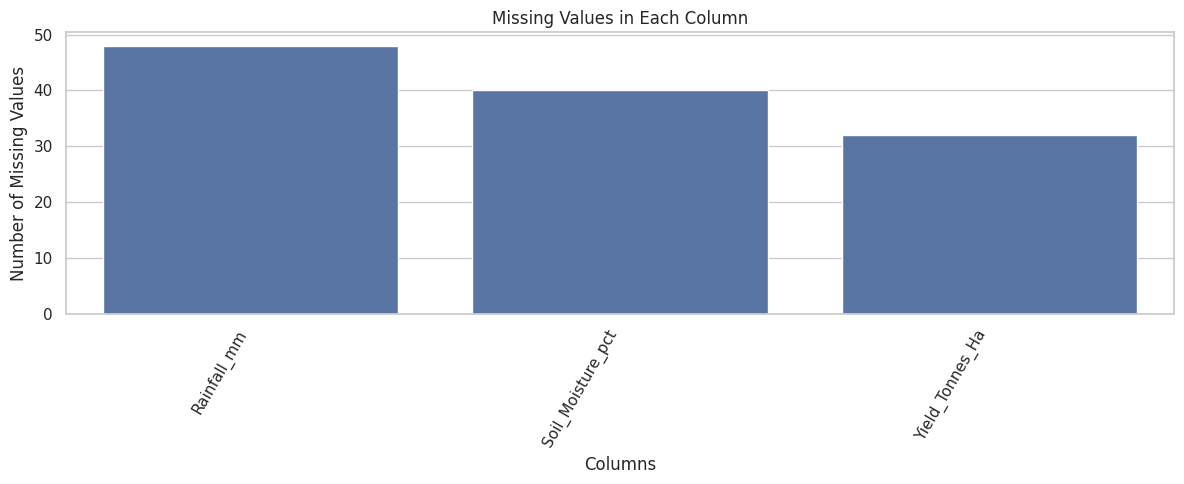

In [12]:
# Visualize missing values
plt.figure(figsize=(12, 5))
missing_plot = missing [missing > 0]
if len(missing_plot) > 0:
  sns.barplot(x= missing_plot.index, y= missing_plot.values)
  plt.xticks(rotation = 60, ha="right")
  plt.ylabel("Number of Missing Values")
  plt.xlabel("Columns")
  plt.title("Missing Values in Each Column")
  plt.tight_layout()
  plt.show()
else:
  print("No missing values found.")

In [13]:
# Duplicate records

duplicate_count = df.duplicated().sum()
print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [14]:
# Remove duplicate rows

df = df.drop_duplicates().reset_index(drop=True)
print ("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4000, 28)


In [15]:
# Checking datatypes again

df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [16]:
categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique(), "unique values")
    print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [17]:
# Checking missing values after duplicate removal

df.isnull().sum().sort_values(ascending=False).head(10)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


### Missing Value Treatment

Possible Approaches:
*   Removing records only when justified
*   Filling numerical values using an appropriate statistic (mostly median)
*   Filling categorical values using a suitable category or method (mode mainly)

In [18]:
numerical_columns = df.select_dtypes(include=np.number).columns

for col in numerical_columns:
    if df[col].isnull().sum() > 0:
      df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


### Cleaning Summary

A quick summary of the cleaning steps performed above, before proceeding to analysis.

In [19]:
print(f"Final dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Duplicate rows removed: {duplicate_count}")
print(f"Missing values remaining: {df.isnull().sum().sum()}")

Final dataset shape: 4000 rows, 28 columns
Duplicate rows removed: 0
Missing values remaining: 0


In [20]:
# Export cleaned dataset

df.to_csv('cleaned_seasonal_agriculture_performance_dataset.csv', index=False)
print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


## 4. Feature / Variable Review

In [21]:
# Numerical and categorical columns

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:", numerical_columns)
print("\nCategorical columns:", categorical_columns)


Numerical columns: ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns: ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


## 5. Statistical Analysis

In [22]:
# Descriptive Statistics

stats = df[numerical_columns].describe().T
stats["range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]
stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20","1,315.20",460.40
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [23]:
# Median and Standard Deviation

statistical_summary = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Std_Dev": df[numerical_columns].std(),
    "Min": df[numerical_columns].min(),
    "Max": df[numerical_columns].max(),
})

statistical_summary

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [24]:
season_summary = df.groupby("Season")[numerical_columns].agg(['mean', 'median', 'std'])
season_summary

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16      304.65 288.20 157.24   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.15   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.07   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.28   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.10 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.94         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.94         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.63   1.94 14.39             46.31  13.24 135.70   
Rabi              5.04   1.67 12.75             41.49  11.08 121.90   
Zaid              4.64   1.46 11.27             38.89   9.97 112.00   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                         mean    median       std           mean     median   
Season                                                                        
Kharif              44,850.91 25,793.00 30,301.56     531,804.41 524,840.00   
Rabi                44,747.97 26,041.00 30,309.56     513,836.58 506,733.00   
Zaid                44,212.03 25,749.50 30,086.23     543,976.73 534,833.00   

                  Revenue_INR                       Profit_INR             \
              std        mean     median        std       mean     median   
Season                                                                      
Kharif 298,487.69  710,719.06 520,196.00 708,710.37 178,914.65  38,808.00   
Rabi   288,386.89  601,526.05 438,156.00 584,545.52  87,689.47  -3,187.00   
Zaid   297,576.86  519,171.90 373,700.50 509,524.55 -24,804.82 -62,144.00   

                  Water_Used_m3             

## 6. Univariate Analysis


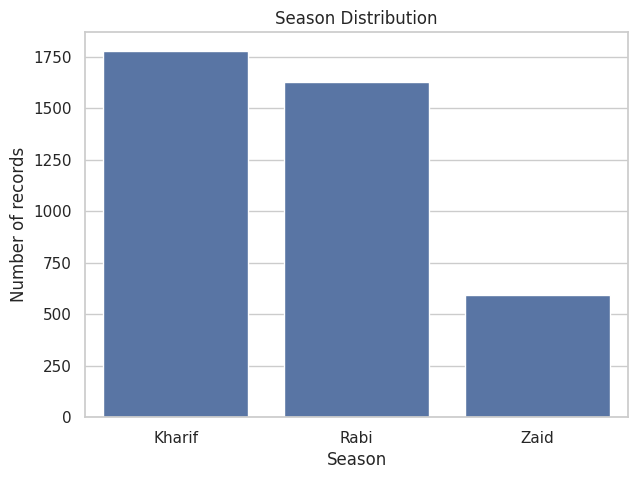

<Figure size 640x480 with 0 Axes>

In [25]:
# Univariate: Season distribution

plt.figure(figsize = (7,5))
sns.countplot(data = df, x = "Season")
plt.title("Season Distribution")
plt.xlabel("Season")
plt.ylabel("Number of records")
plt.show()
plt.tight_layout()
plt.show()

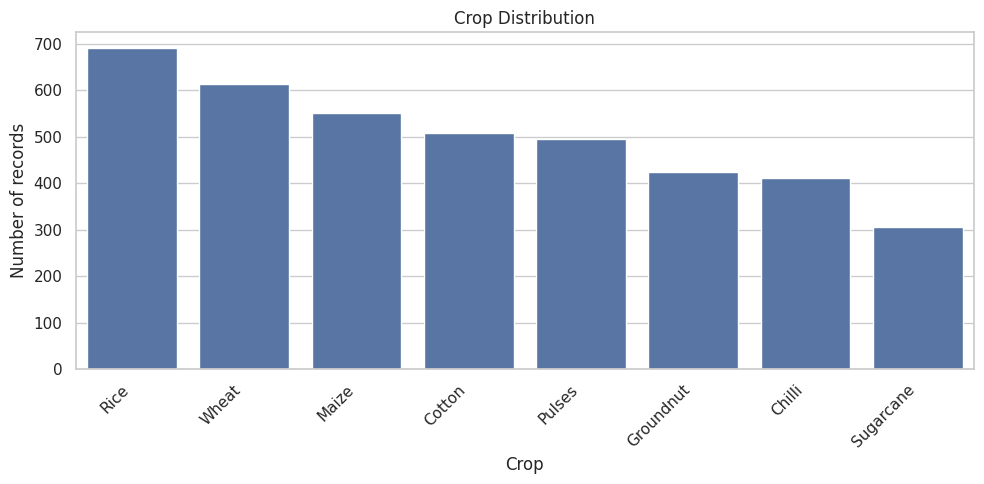

In [26]:
# Univariate : Crop distribution

plt.figure(figsize = (10,5))
sns.countplot(data = df, x = "Crop", order =df["Crop"].value_counts().index)
plt.xticks(rotation=45, ha ="right")
plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

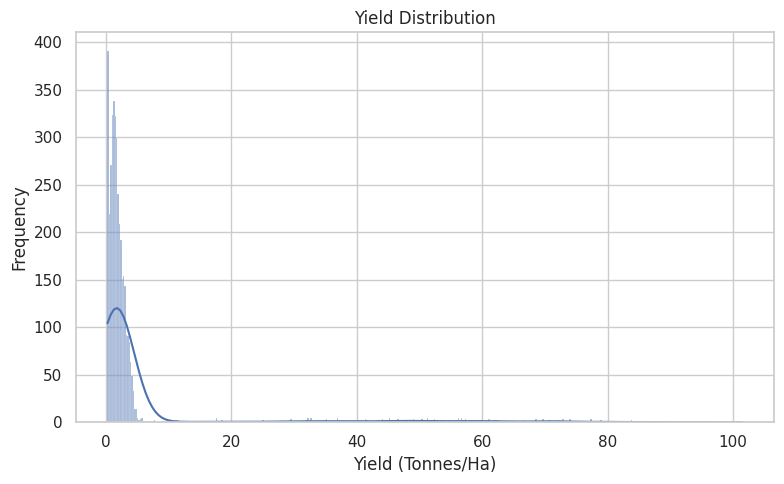

In [27]:
# Univariate : Yield distribution

plt.figure(figsize = (8,5))
sns.histplot(data = df, x = "Yield_Tonnes_Ha", kde = True)
plt.title("Yield Distribution")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

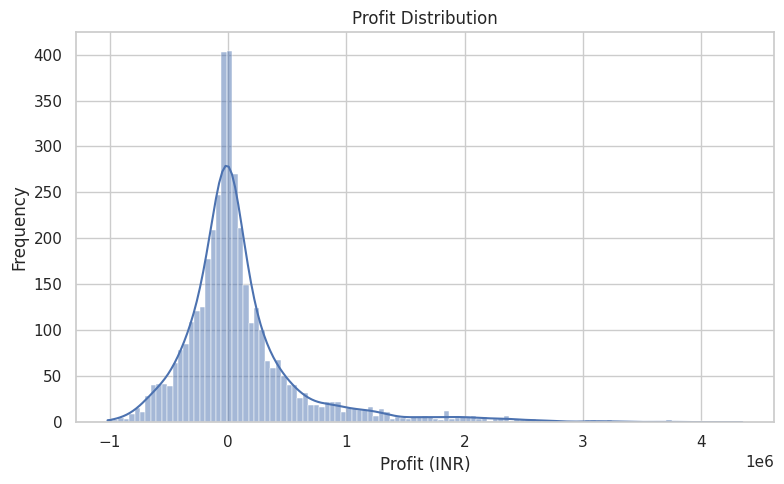

In [28]:
# Univariate : Profit distribution

plt.figure(figsize = (8,5))
sns.histplot(data = df, x = "Profit_INR", kde = True)
plt.title("Profit Distribution")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

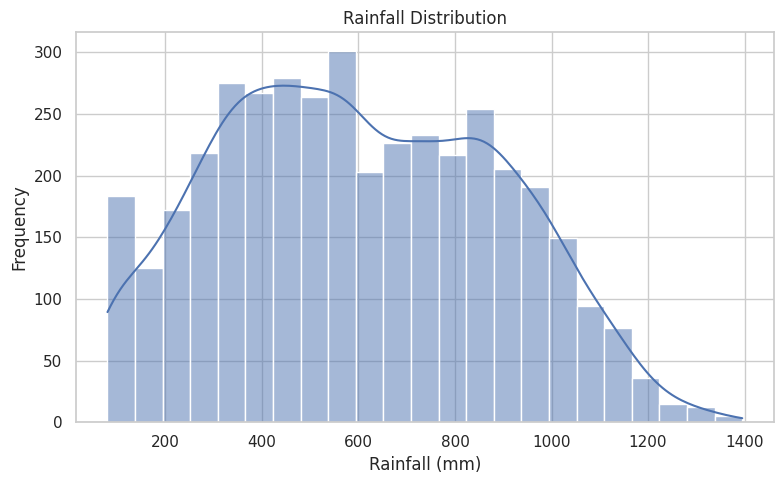

In [29]:
# Univariate : Rainfall distribution

plt.figure(figsize = (8,5))
sns.histplot(data = df, x = "Rainfall_mm", kde = True)
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

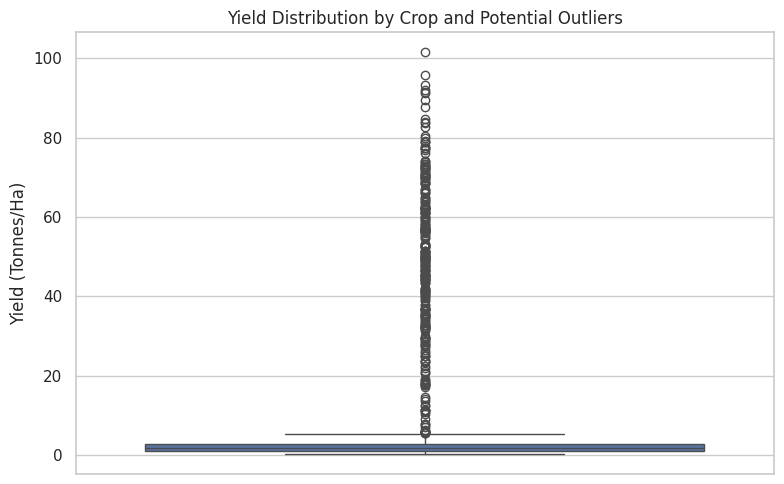

In [30]:
# Univariate: Boxplot for yield

plt.figure(figsize = (8,5))
sns.boxplot(data = df, y = "Yield_Tonnes_Ha")
plt.title("Yield Distribution by Crop and Potential Outliers")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()


## 7. Outlier Analysis

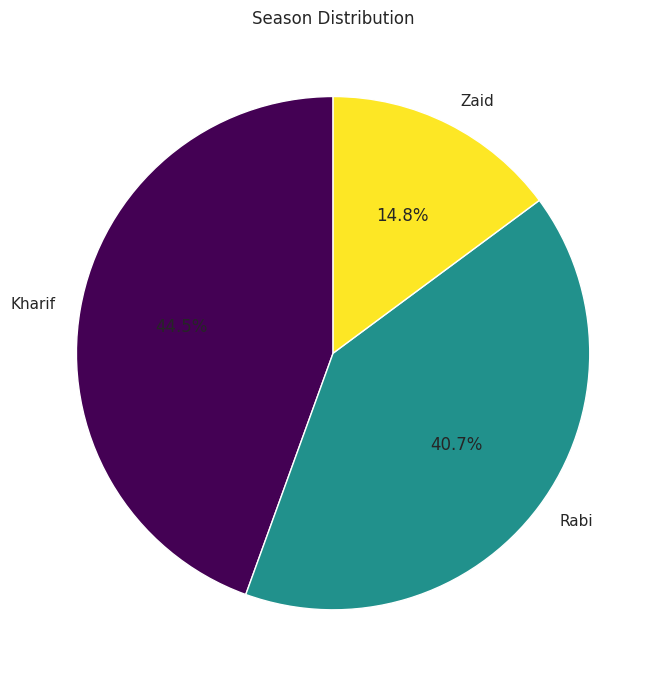

In [31]:
# Univariate: Season distribution (Pie Chart)

plt.figure(figsize=(7, 7))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap = "viridis")
plt.title('Season Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [32]:
# IQR based outlier summary for numerical columns

outlier_summary = []

for col in numerical_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    # Correctly calculate the count of outliers
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        'Column': col,
        'Outlier_Count': count,
        'Lower_Bound': lower,
        'Upper_Bound': upper,
        'Outlier_Percentage': round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values("Outlier_Count", ascending = False)

outlier_summary

,Column,Outlier_Count,Lower_Bound,Upper_Bound,Outlier_Percentage
18,Profit_INR,404,"-696,111.00","763,567.00",10.10
14,Production_Tonnes,333,-23.98,53.36,8.33
20,Water_Efficiency_t_per_1000m3,322,-3.57,10.38,8.05
13,Yield_Tonnes_Ha,302,-1.62,5.50,7.55
19,Water_Used_m3,276,"-6,072.75","16,171.25",6.90
17,Revenue_INR,240,"-736,519.00","1,780,911.00",6.00
9,Potassium_kg_ha,32,30.10,179.70,0.80
4,Sunlight_Hours_Day,26,4.35,10.35,0.65
8,Phosphorus_kg_ha,16,11.40,104.20,0.40
10,Fertilizer_kg_ha,15,19.14,352.04,0.38


**Note on outlier treatment:** The outliers identified above (particularly in Profit, Production, and Water Efficiency) are not removed from the dataset. They likely represent genuine extreme performers — both very high and very low — rather than data entry errors, and removing them would hide real variation that seasonal agricultural data is expected to show. This is explored further in the Key Insights section.

## 8. Bivariate Analysis

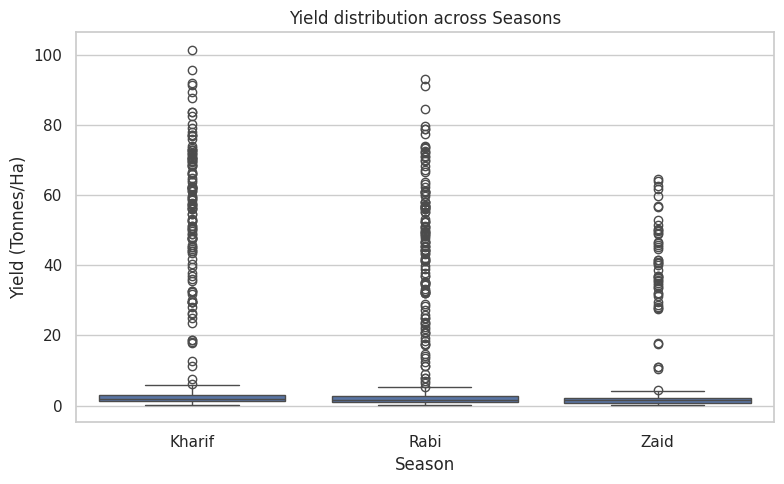

In [33]:
# Bivariate : Season vs Yield

plt.figure(figsize = (8,5))
sns.boxplot(data = df, x = "Season", y = "Yield_Tonnes_Ha")
plt.title("Yield distribution across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

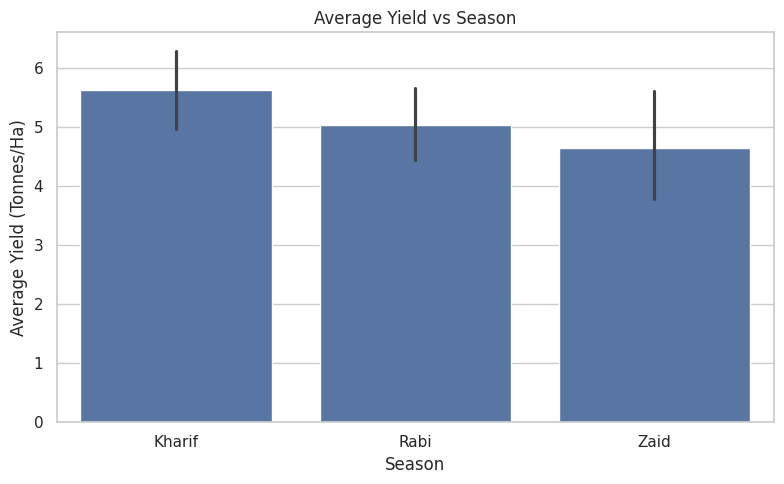

In [34]:
# Barplot for Bivariate Analysis : Average yield vs Season

plt.figure(figsize = (8,5))
sns.barplot(data = df, x = "Season", y = "Yield_Tonnes_Ha")
plt.title("Average Yield vs Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

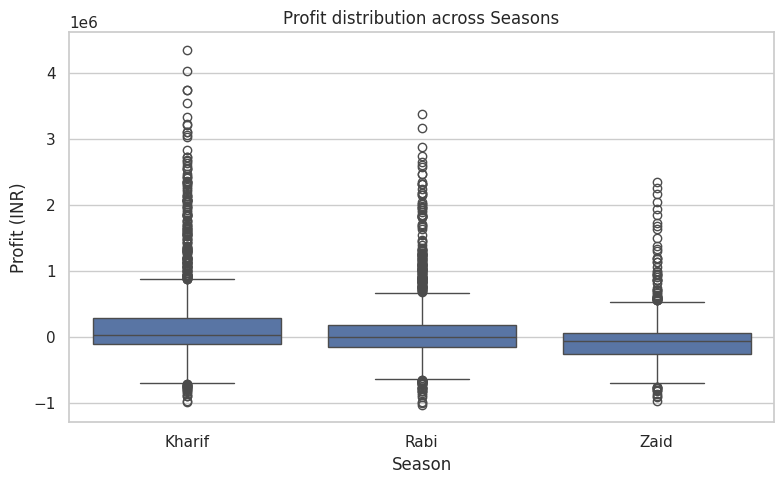

In [35]:
# Bivariate : Season vs Profit

plt.figure(figsize = (8,5))
sns.boxplot(data = df, x = "Season", y = "Profit_INR")
plt.title("Profit distribution across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

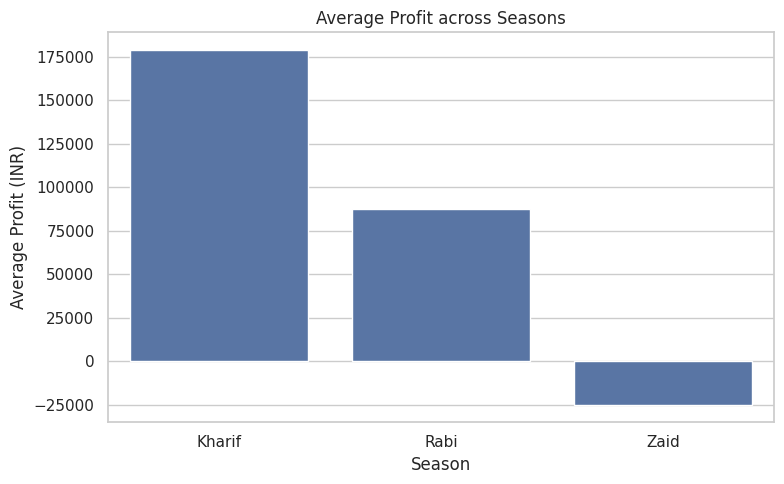

In [36]:
plt.figure(figsize = (8,5))
sns.barplot(data = df, x = "Season", y = "Profit_INR", errorbar = None)
plt.title("Average Profit across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

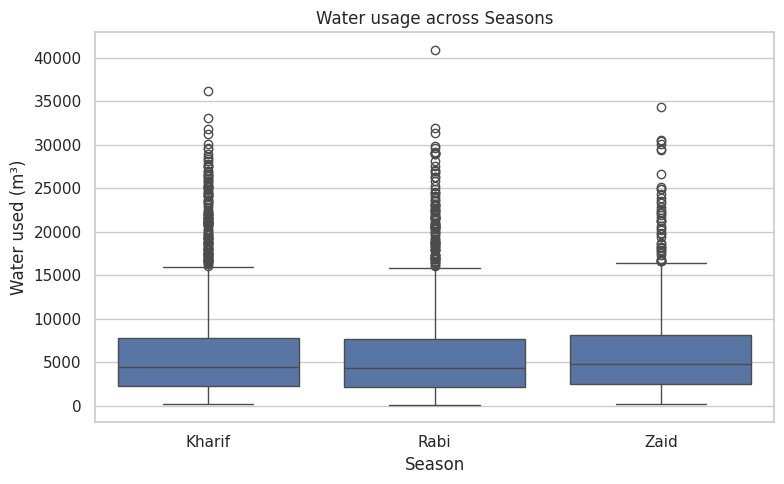

In [37]:
# Bivariate: Water used vs Season

plt.figure(figsize = (8,5))
sns.boxplot(data = df, x = "Season", y = "Water_Used_m3")
plt.title("Water usage across Seasons")
plt.xlabel("Season")
plt.ylabel("Water used (m³)")
plt.tight_layout()
plt.show()

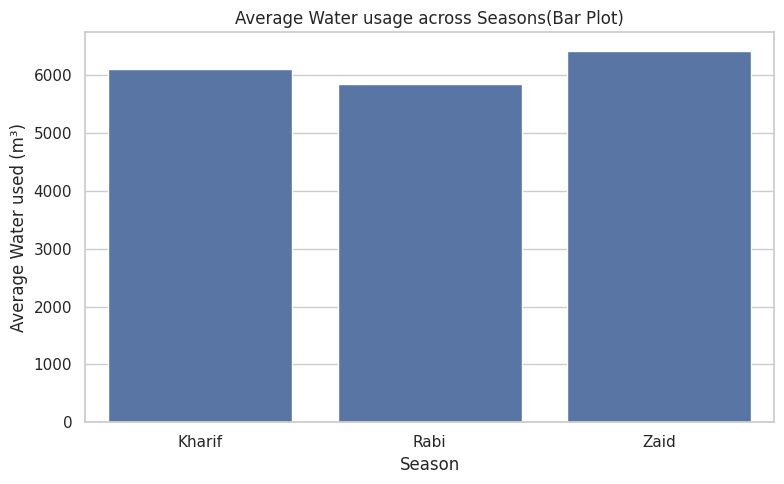

In [38]:
plt.figure(figsize = (8,5))
sns.barplot(data = df, x = "Season", y = "Water_Used_m3", errorbar = None)
plt.title("Average Water usage across Seasons(Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Water used (m³)")
plt.tight_layout()
plt.show()

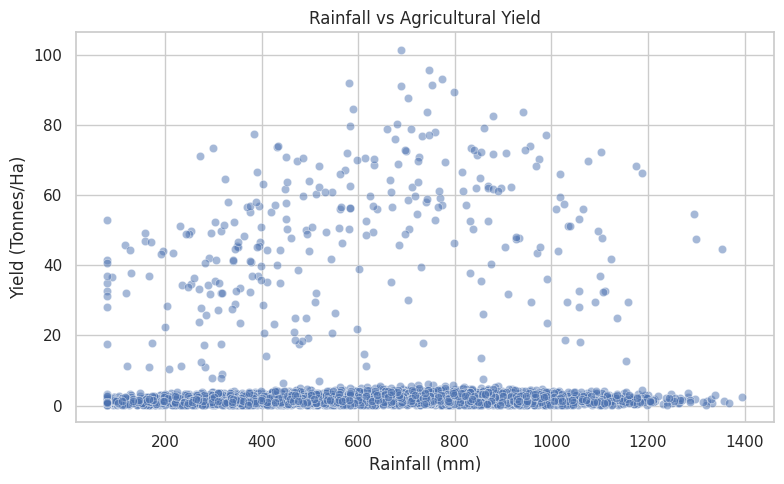

In [39]:
# Bivariate: Rainfall vs Yield

plt.figure(figsize = (8,5))
sns.scatterplot(data = df, x = "Rainfall_mm", y = "Yield_Tonnes_Ha", alpha = 0.5)
plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

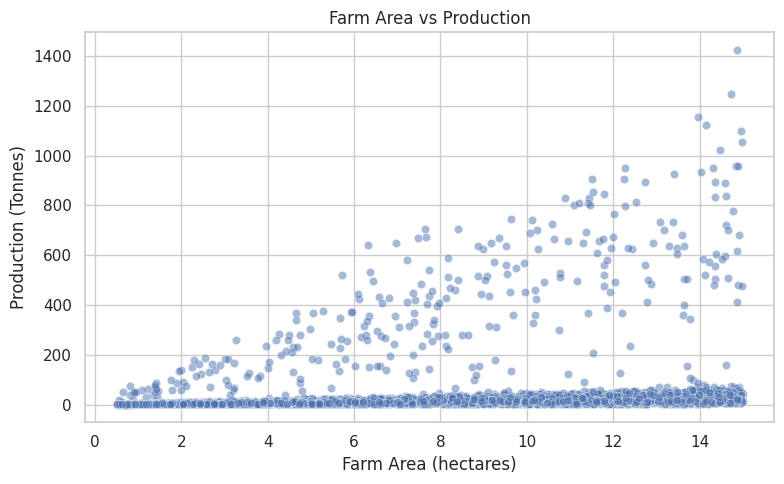

In [40]:
# Bivariate: Farm area vs Production

plt.figure(figsize = (8,5))
sns.scatterplot(data = df, x = "Farm_Area_Hectares", y = "Production_Tonnes", alpha = 0.5)
plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (hectares)")
plt.ylabel("Production (Tonnes)")
plt.tight_layout()
plt.show()

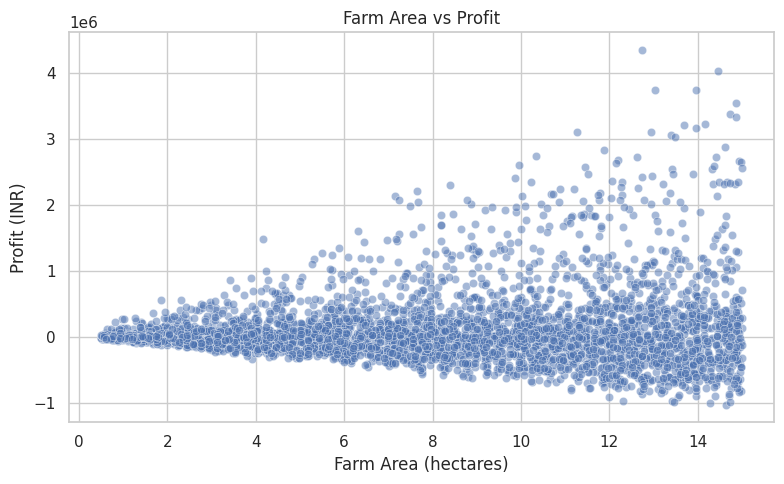

In [41]:
# Bivariate: Farm area vs Profit

plt.figure(figsize = (8,5))
sns.scatterplot(data = df, x = "Farm_Area_Hectares", y = "Profit_INR", alpha = 0.5)
plt.title("Farm Area vs Profit")
plt.xlabel("Farm Area (hectares)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

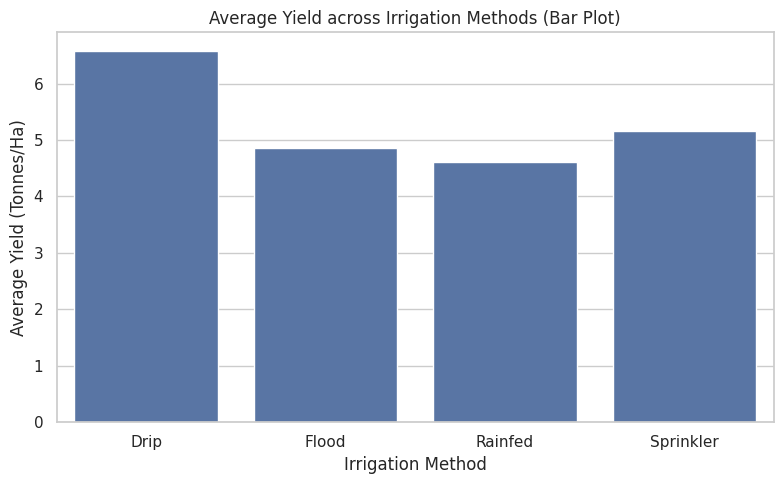

In [42]:
plt.figure(figsize = (8,5))
sns.barplot(data = df, x = "Irrigation_Method", y = "Yield_Tonnes_Ha", errorbar = None)
plt.title("Average Yield across Irrigation Methods (Bar Plot)")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

## 9. Multivariate Analysis



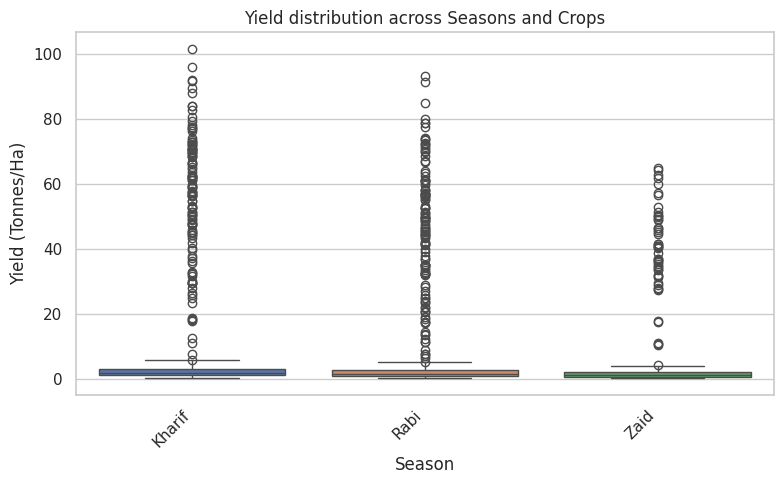

In [43]:
# Multivariate: Season, Crop and Yield

plt.figure(figsize = (8,5))
sns.boxplot(data = df, x = "Season", y = "Yield_Tonnes_Ha", hue = "Season")
plt.xticks(rotation = 45, ha = "right")
plt.title("Yield distribution across Seasons and Crops")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

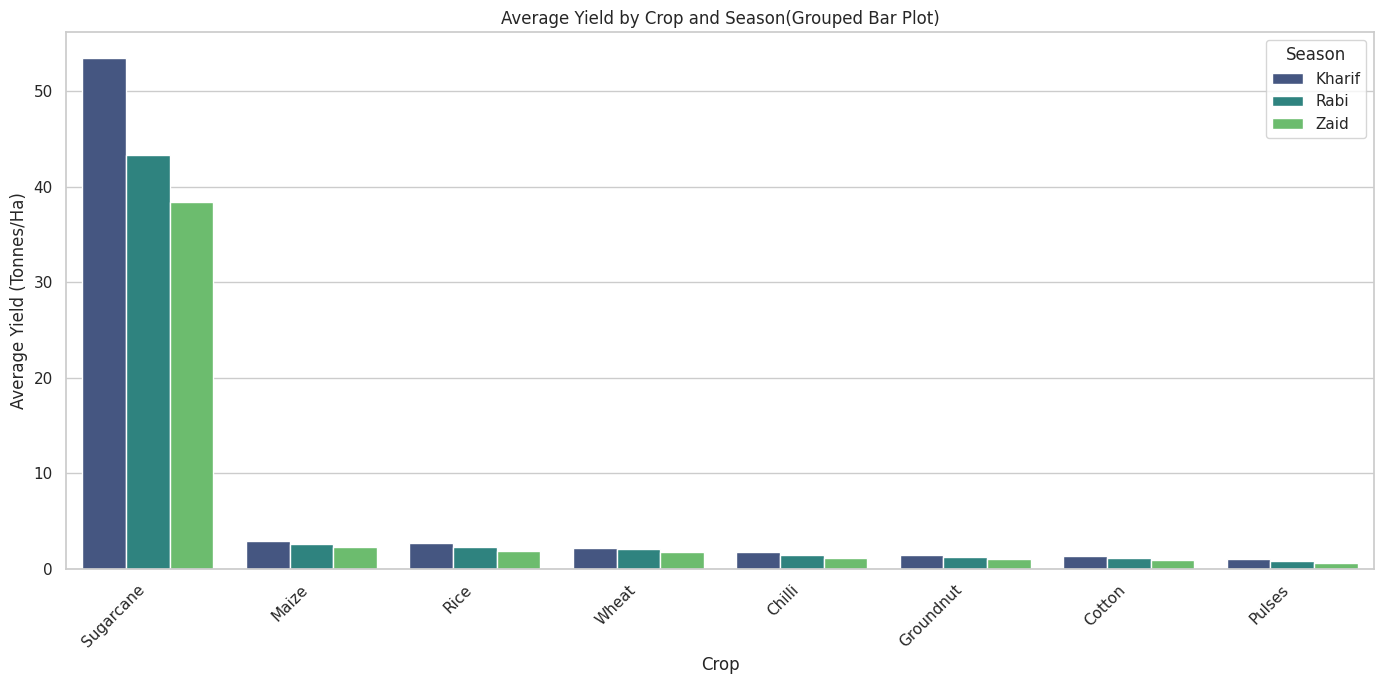

In [44]:
# Multivariate: Grouped Bar Plot of Average Yield by Crop and Season

import pandas as pd
crop_season_summary = df.groupby(["Season", "Crop"]).agg(
    Average_Yield= ("Yield_Tonnes_Ha", "mean"),
    Average_Water_Efficiency= ("Water_Efficiency_t_per_1000m3", "mean"),
    Average_Profit = ("Profit_INR", "mean")
).round(2).sort_values(["Season", "Average_Yield"], ascending = [True,False])

plt.figure(figsize = (14, 7))
sns.barplot(data = crop_season_summary.reset_index(), x = "Crop", y = "Average_Yield", hue = "Season", palette = "viridis")
plt.title("Average Yield by Crop and Season(Grouped Bar Plot)")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation = 45, ha = "right")
plt.legend(title = "Season")
plt.tight_layout()
plt.show()

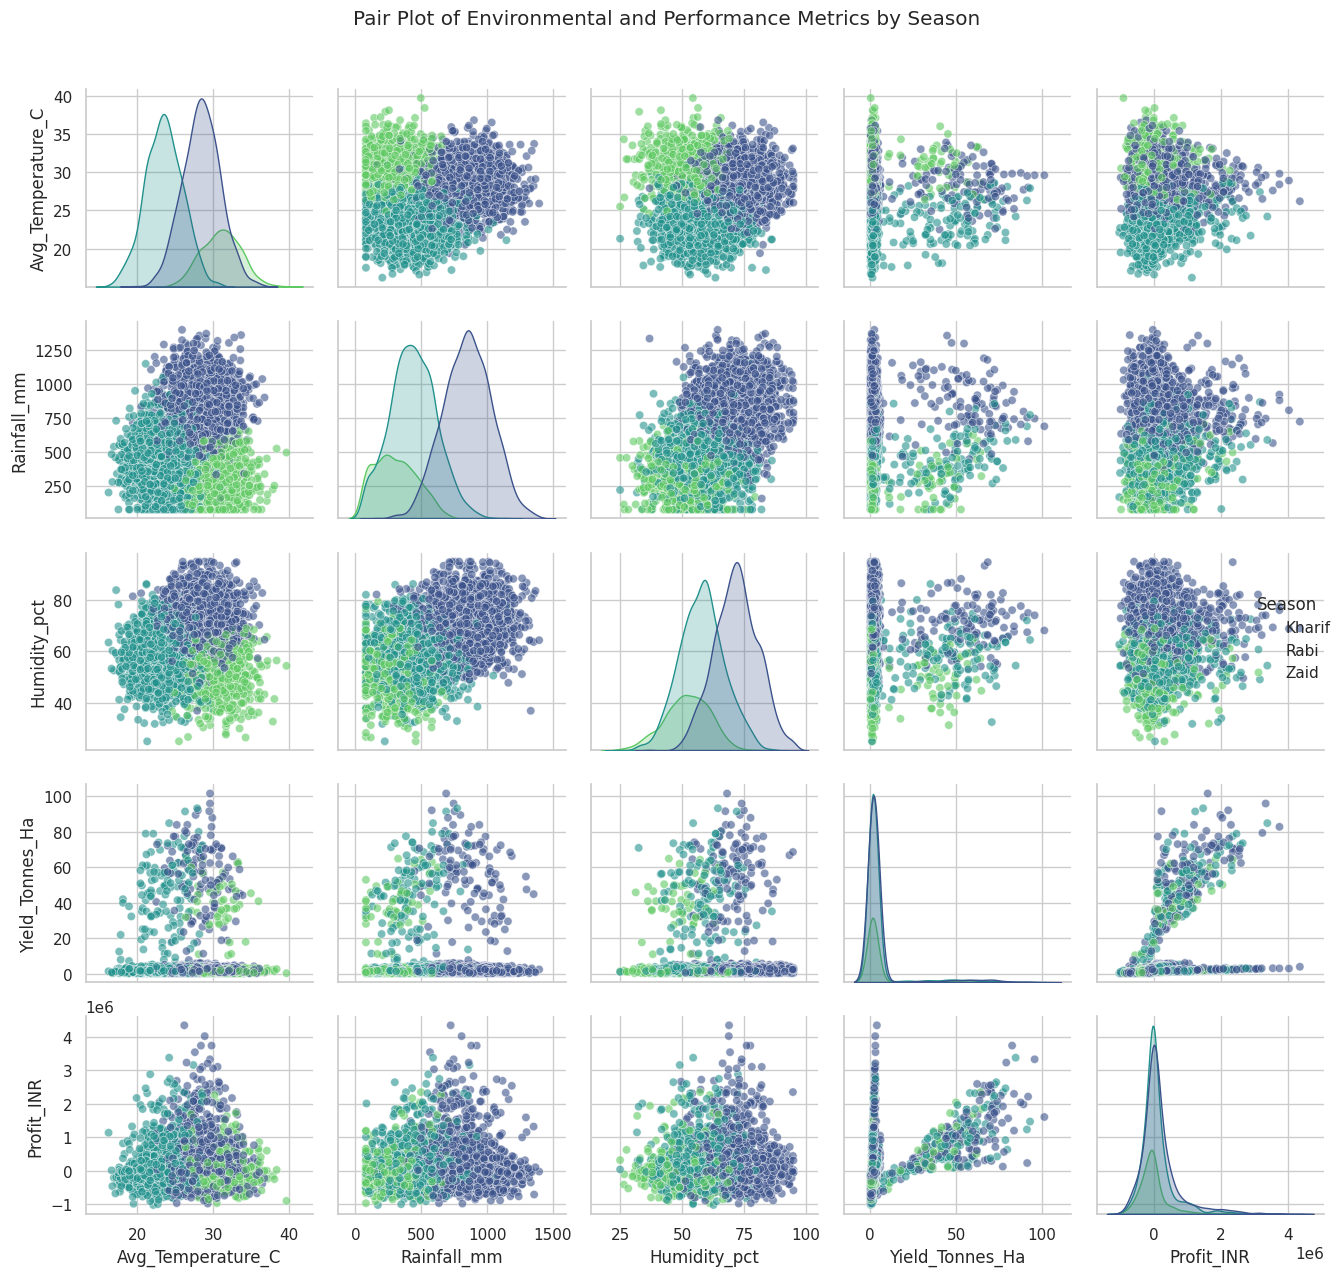

In [45]:
# Multivariate: Pair Plot of Key Environmental and Performance Metrics by Season

selected_columns = ['Avg_Temperature_C','Rainfall_mm','Humidity_pct','Yield_Tonnes_Ha','Profit_INR','Season']
sns.pairplot(df[selected_columns], hue = 'Season', palette= 'viridis',plot_kws={'alpha':0.6})
plt.suptitle('Pair Plot of Environmental and Performance Metrics by Season', y = 1.02)
plt.tight_layout()
plt.show()

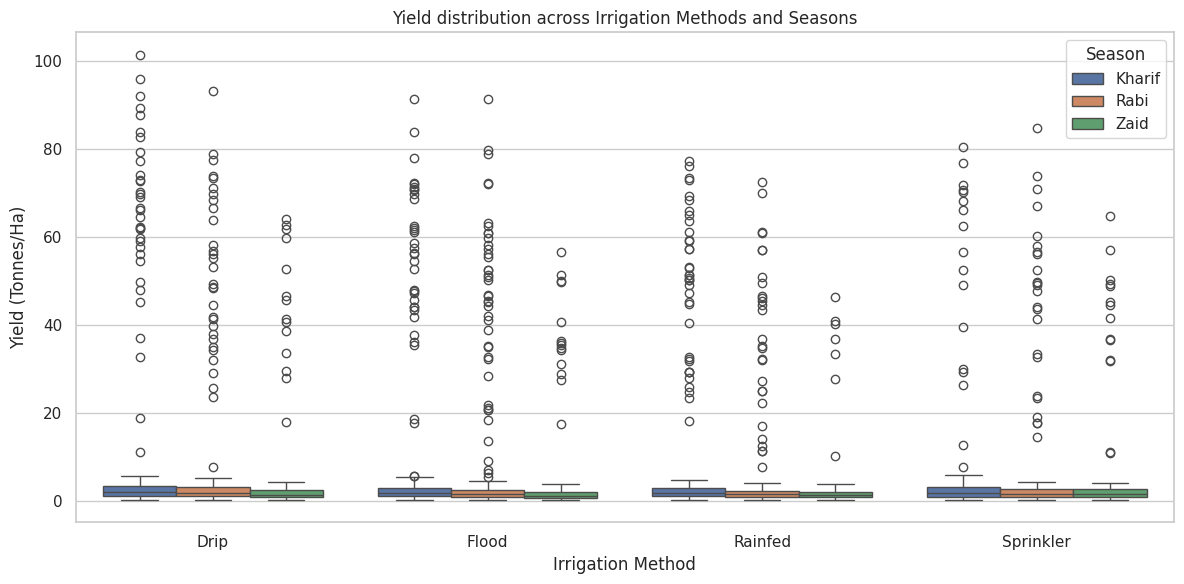

In [46]:
# Multivariate: Season, Irrigation and Yield

plt.figure(figsize = (12,6))
sns.boxplot(data = df, x = "Irrigation_Method", y = "Yield_Tonnes_Ha", hue = "Season")
plt.title("Yield distribution across Irrigation Methods and Seasons")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (Tonnes/Ha)")
plt.legend(title = "Season")
plt.tight_layout()
plt.show()

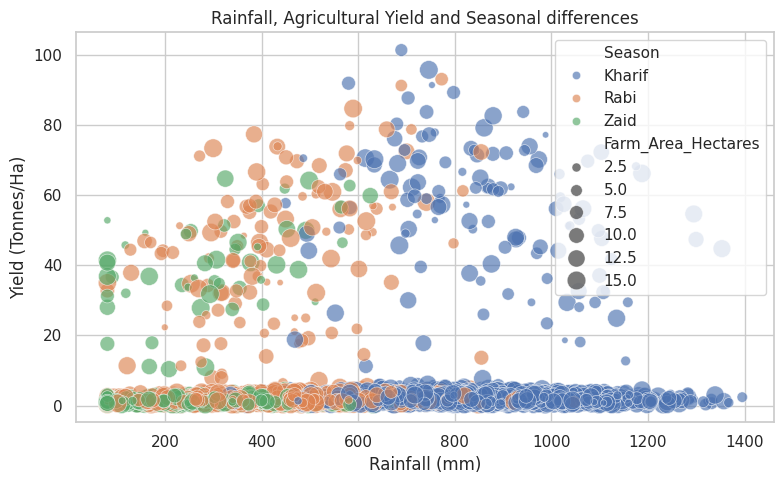

In [47]:
# Multivariate: Rainfall, Yield and Season

plt.figure(figsize = (8,5))
sns.scatterplot(data = df, x = "Rainfall_mm", y = "Yield_Tonnes_Ha", hue = 'Season', size = 'Farm_Area_Hectares', sizes=(20,180), alpha =0.65)
plt.title("Rainfall, Agricultural Yield and Seasonal differences")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

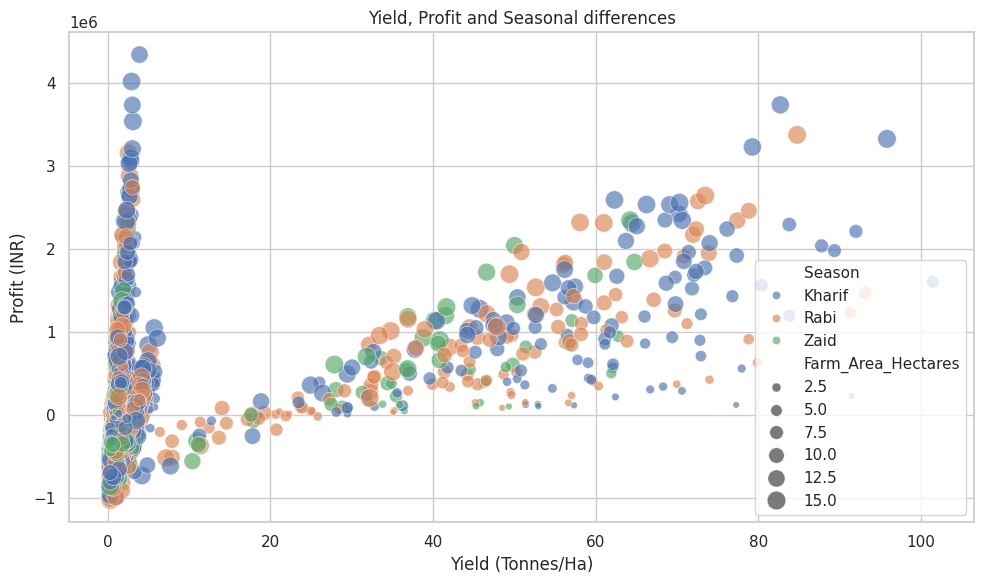

In [48]:
# Multivariate: Yield, Profit and Seasonal differences

plt.figure(figsize = (10,6))
sns.scatterplot(data = df, x = "Yield_Tonnes_Ha", y = "Profit_INR", hue = 'Season', size = 'Farm_Area_Hectares', sizes=(20,180), alpha =0.65)
plt.title("Yield, Profit and Seasonal differences")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

## 10. Correlation Analysis

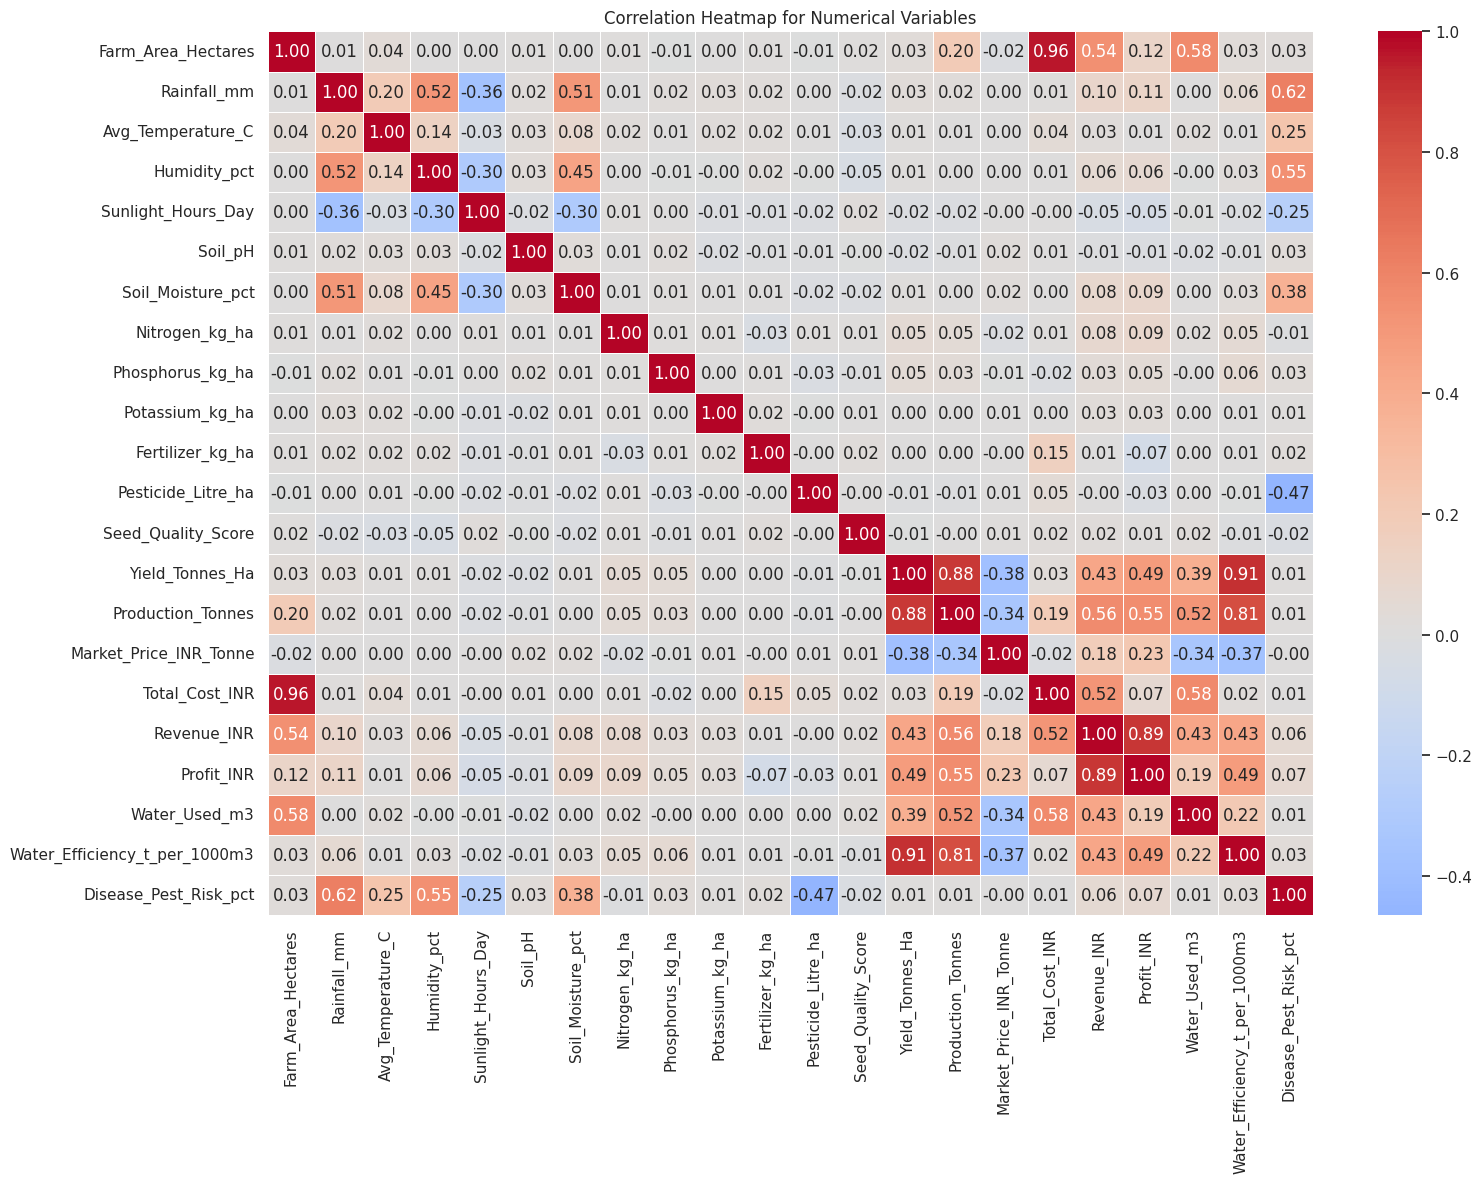

In [49]:
# Correlation Heatmap for numerical variables

plt.figure(figsize=(16,12))
corr= df[numerical_columns].corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths =0.5)
plt.title("Correlation Heatmap for Numerical Variables")
plt.tight_layout()
plt.show()

## 11. Seasonal Comparison

In [50]:
# General Season Summary

season_metrics = df.groupby("Season").agg(
    Records= ("Farm_ID","count"),
    Average_Yield= ("Yield_Tonnes_Ha", "mean"),
    Total_Production= ("Production_Tonnes", "sum"),
    Total_Water_Used= ("Water_Used_m3", "sum"),
    Total_Profit = ("Profit_INR", "sum"),
    Average_Profit = ("Profit_INR", "mean"),
).round(2)

season_metrics

,Records,Average_Yield,Total_Production,Total_Water_Used,Total_Profit,Average_Profit
Season,,,,,,
Kharif,1779,5.63,"82,387.61",10855816,318289158,"178,914.65"
Rabi,1627,5.04,"67,498.88",9513048,142670768,"87,689.47"
Zaid,594,4.64,"23,098.35",3813417,-14734066,"-24,804.82"


In [51]:
# Compare Crop performance within each Season

crop_season_summary = df.groupby(["Season", "Crop"]).agg(
    Average_Yield= ("Yield_Tonnes_Ha", "mean"),
    Average_Water_Efficiency= ("Water_Efficiency_t_per_1000m3", "mean"),
    Average_Profit = ("Profit_INR", "mean")
).round(2).sort_values(["Season", "Average_Yield"], ascending = [True,False])

crop_season_summary

Average_Yield  Average_Water_Efficiency  Average_Profit
Season Crop                                                              
Kharif Sugarcane          53.46                     36.00    1,000,790.81
       Maize               2.97                      6.05      -39,332.67
       Rice                2.70                      2.17      -64,903.40
       Wheat               2.25                      4.76     -105,871.87
       Chilli              1.73                      3.26      954,380.42
       Groundnut           1.48                      3.58      108,265.44
       Cotton              1.37                      2.13      216,999.55
       Pulses              1.04                      3.35       43,338.90
Rabi   Sugarcane          43.29                     27.92      731,612.86
       Maize               2.60                      5.46      -89,133.40
       Rice                2.32                      1.84      -98,427.87
       Wheat               2.06                      4.69     -119,954.57
       Chilli              1.47                      2.89      638,572.50
       Groundnut           1.23                      2.90       10,416.54
       Cotton              1.20                      1.94      107,343.59
       Pulses              0.88                      2.70      -14,309.14
Zaid   Sugarcane          38.42                     23.39      583,635.80
       Maize               2.29                      4.75     -194,049.17
       Rice                1.90                      1.53     -227,239.34
       Wheat               1.75                      4.02     -193,208.95
       Chilli              1.20                      2.20      448,659.09
       Groundnut           1.04                      2.47      -68,872.50
       Cotton              0.96                      1.49      -53,925.34
       Pulses              0.67                      1.95     -139,227.81

### Statistical Significance of Seasonal Differences

The descriptive comparison above shows visible differences in yield and profit across seasons — but visible differences don't necessarily mean they're statistically real. A one-way ANOVA test is used here to check whether yield and profit genuinely differ by season, or whether the differences could be due to random variation.

In [52]:
from scipy import stats

# ANOVA: does Yield differ significantly across seasons?
yield_groups = [group["Yield_Tonnes_Ha"].dropna() for name, group in df.groupby("Season")]
f_yield, p_yield = stats.f_oneway(*yield_groups)

# ANOVA: does Profit differ significantly across seasons?
profit_groups = [group["Profit_INR"].dropna() for name, group in df.groupby("Season")]
f_profit, p_profit = stats.f_oneway(*profit_groups)

print(f"Yield ANOVA  — F: {f_yield:.3f}, p-value: {p_yield:.5f}")
print("Result:", "Significant difference across seasons" if p_yield < 0.05 else "No significant difference across seasons")

print(f"\nProfit ANOVA — F: {f_profit:.3f}, p-value: {p_profit:.5f}")
print("Result:", "Significant difference across seasons" if p_profit < 0.05 else "No significant difference across seasons")

Yield ANOVA  — F: 1.544, p-value: 0.21368
Result: No significant difference across seasons

Profit ANOVA — F: 34.292, p-value: 0.00000
Result: Significant difference across seasons


**Interpretation:** Profit differs significantly across seasons, but yield does not. This is an important distinction — it suggests the seasonal decline in profit isn't primarily explained by lower physical output (yield), but by other factors layered on top, such as cost structure, market pricing, or the crop mix grown in each season. This is explored further in the Key Insights section below.

## 12. Custom Analysis: Beyond the Standard Framework
This section presents four original analyses, each designed to investigate a specific question about seasonal agricultural performance using derived metrics or statistical tests not applied in the standard analysis above.

### 12.1 Return on Investment (ROI) by Season and Crop

**Question:** Which season-crop combinations deliver the most efficient return on money invested — not just the highest raw profit?

**Why it matters:** Raw profit favors farms with larger scale or higher-cost operations. ROI (Profit ÷ Cost) measures how efficiently invested money is converted into return, revealing which season-crop combinations are genuinely most economical, independent of farm size.

    Season       Crop  ROI_percent
6   Kharif  Sugarcane       187.15
0   Kharif     Chilli       173.73
8     Rabi     Chilli       133.65
14    Rabi  Sugarcane       131.87
22    Zaid  Sugarcane       104.40
16    Zaid     Chilli        78.24
1   Kharif     Cotton        43.35
2   Kharif  Groundnut        27.21
9     Rabi     Cotton        22.54
4   Kharif     Pulses        13.42


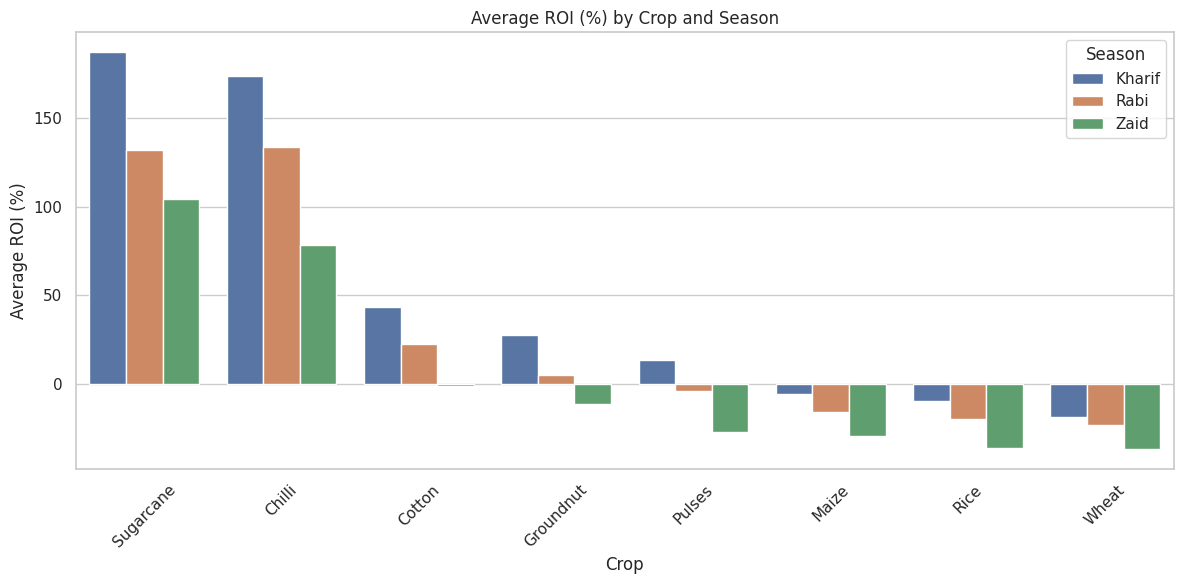

In [53]:
# Analysis 1: ROI by Season and Crop

df['ROI_percent'] = (df['Profit_INR'] / df['Total_Cost_INR']) * 100

roi_summary = df.groupby(["Season", "Crop"])['ROI_percent'].mean().round(2).reset_index()
roi_summary = roi_summary.sort_values("ROI_percent", ascending=False)
print(roi_summary.head(10))

plt.figure(figsize=(12,6))
sns.barplot(data=roi_summary, x="Crop", y="ROI_percent", hue="Season")
plt.xticks(rotation=45)
plt.xlabel("Crop")
plt.ylabel("Average ROI (%)")
plt.title("Average ROI (%) by Crop and Season")
plt.tight_layout()
plt.show()

### 12.2 Regional Yield Stability Across Seasons

**Question:** Are some states more sensitive to seasonal change than others, and are yield differences across states statistically significant or could they be due to chance?

**Why it matters:** Average yield alone doesn't show consistency. Coefficient of variation (CV) measures how stable a state's yield is across seasons, identifying which regions may need targeted seasonal planning. A one-way ANOVA then tests whether the yield differences observed across states are statistically significant, rather than assuming visual differences are meaningful.

                mean   std  CV_percent
State                                 
Andhra Pradesh  4.63 12.82      276.94
Tamil Nadu      4.88 12.85      263.56
Gujarat         5.66 14.68      259.38
Maharashtra     5.02 12.78      254.73
Madhya Pradesh  4.99 12.60      252.52
Telangana       5.04 12.26      242.94
Karnataka       5.69 13.78      242.32
Punjab          6.12 14.67      239.64


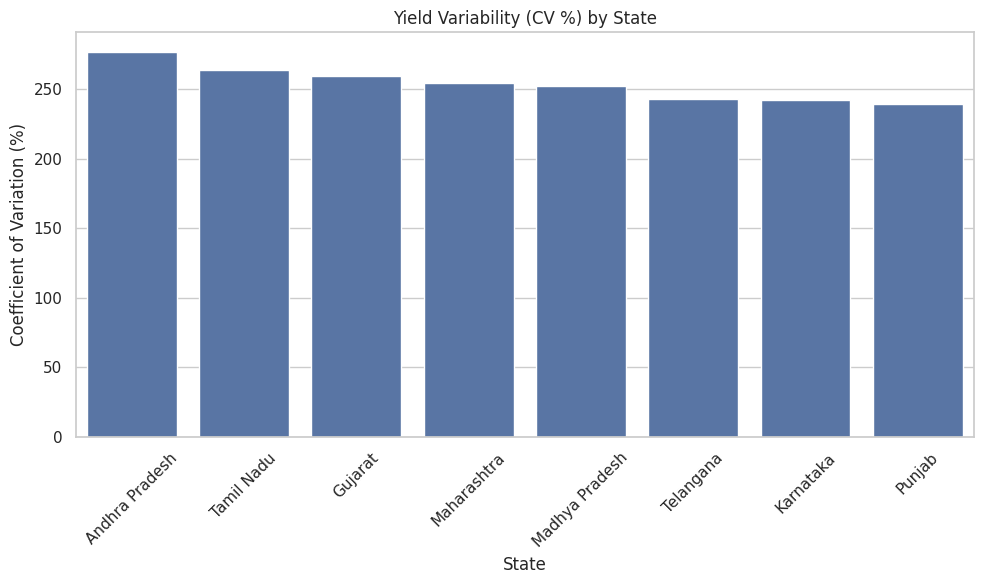


ANOVA result — F-statistic: 0.723, p-value: 0.65282
No significant difference across states


In [54]:
import scipy.stats as stats

# Analysis 2: State-wise yield stability + ANOVA

state_variability = df.groupby("State")["Yield_Tonnes_Ha"].agg(['mean', 'std'])
state_variability['CV_percent'] = (state_variability['std'] / state_variability['mean'] * 100).round(2)
state_variability = state_variability.sort_values('CV_percent', ascending=False)
print(state_variability)

plt.figure(figsize=(10,6))
sns.barplot(data=state_variability.reset_index(), x="State", y="CV_percent")
plt.xticks(rotation=45)
plt.xlabel("State")
plt.ylabel("Coefficient of Variation (%)")
plt.title("Yield Variability (CV %) by State")
plt.tight_layout()
plt.show()

# ANOVA: is yield significantly different across states?

state_groups = [group["Yield_Tonnes_Ha"].values for name, group in df.groupby("State")]
f_stat, p_value = stats.f_oneway(*state_groups)
print(f"\nANOVA result — F-statistic: {f_stat:.3f}, p-value: {p_value:.5f}")
print("Significant difference across states" if p_value < 0.05 else "No significant difference across states")

### 12.3 Irrigation Method Efficiency Within Each Season

**Question:** Does the best-performing irrigation method change depending on the season, or does one method consistently outperform others regardless of season?

**Why it matters:** Irrigation method and season are each analyzed separately elsewhere, but their interaction hasn't been tested. If effectiveness depends on season, that has direct practical value for planning irrigation choices seasonally rather than applying one method year-round.

Season             Kharif  Rabi  Zaid
Irrigation_Method                    
Drip                 6.80  6.05  5.30
Flood                3.64  3.48  2.73
Rainfed              8.85  6.87  5.48
Sprinkler            4.62  4.64  4.86


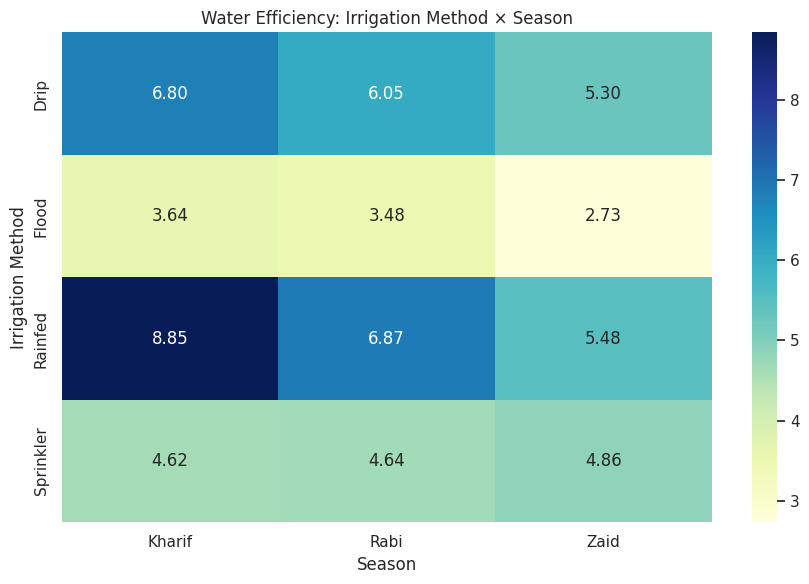

In [55]:
# Analysis 3: Irrigation x Season interaction on Water Efficiency

irrigation_season = df.groupby(["Season", "Irrigation_Method"])['Water_Efficiency_t_per_1000m3'].mean().round(3).reset_index()

pivot_irrigation = irrigation_season.pivot(index="Irrigation_Method", columns="Season", values="Water_Efficiency_t_per_1000m3")
print(pivot_irrigation)

plt.figure(figsize=(9,6))
sns.heatmap(pivot_irrigation, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Water Efficiency: Irrigation Method × Season")
plt.xlabel("Season")
plt.ylabel("Irrigation Method")
plt.tight_layout()
plt.show()

### 12.4 Risk-Adjusted Profitability by Season

**Question:** Which season offers the most reliable return once disease/pest risk is accounted for — not just the highest average profit?

**Why it matters:** Two seasons can show similar average profit while carrying very different levels of disease/pest risk. Combining both into a single risk-adjusted return metric identifies which seasons are dependable versus which are high-reward but high-risk.

            mean    median
Season                    
Kharif  3,585.22    690.64
Rabi    2,153.93    -91.72
Zaid   -1,235.46 -1,722.27


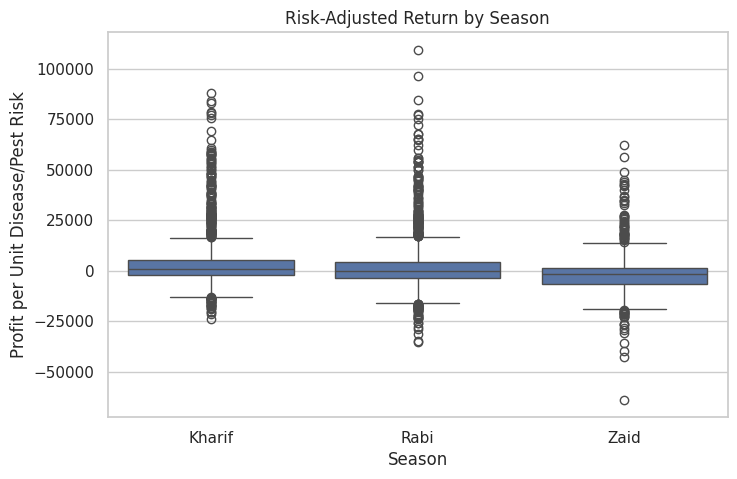

In [56]:
# Analysis 4: Risk-adjusted profitability

df['Risk_Adjusted_Return'] = df['Profit_INR'] / df['Disease_Pest_Risk_pct'].replace(0, np.nan)

risk_adjusted_summary = df.groupby("Season")['Risk_Adjusted_Return'].agg(['mean', 'median']).round(2)
print(risk_adjusted_summary)

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Season", y="Risk_Adjusted_Return")
plt.title("Risk-Adjusted Return by Season")
plt.ylabel("Profit per Unit Disease/Pest Risk")
plt.show()

## 13. Key Insights

The following insights directly address the project's core question — how agricultural performance varies across seasons — and are derived from the analyses above. Each states the observation, supporting evidence, interpretation, and a limitation to avoid overstating the finding.

### **Insight 1:** Profitability falls steadily from Kharif to Zaid, ending in a net loss

**Observation:** Average profit per farm comes in at ₹178,914.65 in Kharif, drops to ₹87,689.47 in Rabi, and turns negative at –₹24,804.82 by Zaid — a decline of well over ₹200,000 between the best and worst-performing season.

**Evidence:** Section 11 seasonal comparison (season_metrics table).

**Interpretation:** This is arguably the clearest finding in the entire dataset — profit doesn't fluctuate unpredictably across seasons, it falls in a steady, consistent order, and the size of that drop makes it impossible to dismiss as noise. It speaks directly to the project's central question about how performance shifts across seasons.

**Limitation:** This is an average across every crop grown in each season, so it shouldn't be read as "no farm makes money in Zaid" — crop choice clearly plays a moderating role, as Insight 6 shows.

### **Insight 2:** Zaid's poor performance lines up closely with harsher environmental conditions

**Observation:** Rainfall drops sharply across the seasons, from 849mm in Kharif to just 305mm in Zaid, while average temperature climbs to 31°C in Zaid — making it both the driest and the hottest of the three seasons.

**Evidence:** Section 5 seasonal statistical summary.

**Interpretation:** The season with the weakest profit outcome also happens to have the harshest natural conditions, which is a fairly intuitive connection — less rainfall paired with more heat likely means greater irrigation dependence and more stress on crops, right when things are already working against the farmer.

**Limitation:** This is an association between seasonal averages, not a proven cause-and-effect relationship — other factors like crop mix and pricing shift across seasons too.

### **Insight 3:** Water efficiency is the strongest driver of yield, and it declines in step with profit

**Observation:** Water efficiency has the strongest correlation with yield of any variable in the dataset, at r = 0.915, and it follows almost exactly the same seasonal pattern as profit — falling from 5.89 in Kharif to 5.19 in Rabi and down to 4.41 in Zaid.

**Evidence:** Section 10 correlation heatmap; Section 5 seasonal summary.

**Interpretation:** A correlation this strong is rare in real-world data, and the fact that it tracks the same seasonal decline as profit makes water efficiency the most actionable lever identified in this entire analysis for narrowing the seasonal performance gap.

**Limitation:** Correlation doesn't tell us which way the causation runs — efficient watering may be driving higher yield, or healthier, higher-yielding crops may simply be using water more effectively as a result.

### **Insight 4:** There's no single "best" irrigation method — it depends entirely on the season

**Observation:** Rainfed irrigation is by far the most efficient method in Kharif, at 8.85, nearly double Sprinkler's 4.62 — but that lead nearly evaporates by Zaid, where Rainfed drops to 5.48 while Sprinkler holds steady at 4.86.

**Evidence:** Section 12.3 irrigation × season heatmap.

**Interpretation:** Rainfed's huge advantage in Kharif is most likely the monsoon doing the heavy lifting for free — an advantage that disappears once the dry season hits, which means irrigation strategy is genuinely worth revisiting each season rather than locking into one method year-round.

**Limitation:** This only measures efficiency, not the cost or practical feasibility of switching between irrigation methods season to season.

### **Insight 5:** Differences in yield between states aren't actually statistically significant

**Observation:** State average yields range from 4.63 to 6.12 tonnes per hectare — a visible spread — and internal variability within each state is high, with coefficients of variation between 239% and 277%. Yet a one-way ANOVA test returned a p-value of 0.653, far above the 0.05 threshold typically used to call a difference real.

**Evidence:** Section 12.2 ANOVA test.

**Interpretation:** Despite states looking different at a glance, the numbers don't back that up statistically — season turns out to be a far more reliable driver of performance than geography in this dataset, which suggests planning efforts are better spent thinking seasonally rather than regionally.

**Limitation:** A non-significant result doesn't prove there's zero regional effect — it's possible one exists but is simply being masked by how much variation there already is within each state.

### **Insight 6:** A small number of crops manage to stay profitable no matter the season

**Observation:** Sugarcane's return on investment holds up remarkably well across the year — 187% in Kharif, 132% in Rabi, and still 104% in Zaid — while Rice, Wheat, and Maize post a loss in every single season, including Kharif, the strongest season overall.

**Evidence:** Section 11 crop-season summary; Section 12.1 ROI analysis.

**Interpretation:** This adds real nuance to Insight 1 — even Sugarcane's worst season (104% ROI in Zaid) still comfortably beats most other crops' best season. Crop choice, it turns out, can matter more than the season itself, and clearly cushions or worsens the seasonal decline depending on what's planted.

**Limitation:** ROI reflects average returns only — it doesn't capture whether every farmer could realistically switch to these crops given soil suitability, market access, or the capital required.

### **Insight 7:** Zaid isn't just less profitable — it's also a riskier bet relative to its returns

**Observation:** Looking at profit relative to disease and pest risk, Kharif returns about ₹3,585 per unit of risk carried, and Rabi about ₹2,154 — but Zaid comes out negative, at –₹1,235.

**Evidence:** Section 12.4 risk-adjusted profitability analysis.

**Interpretation:** This builds directly on Insight 1 — Zaid's issue isn't only a lower average profit, it's that the return farmers get for the risk they're carrying is actually negative, making it unfavorable on two fronts rather than one.

**Limitation:** This metric assumes risk translates roughly linearly into financial impact, which is a simplification worth keeping in mind.

### **Insight 8:** Extreme values are concentrated almost entirely in profit and production, not environmental conditions

**Observation:** Profit has the highest share of statistical outliers in the dataset by a wide margin, at 10.10% of farms — 404 records — followed by production at 8.33%. Compare that to variables like rainfall or soil pH, which show effectively zero outliers.

**Evidence:** Section 7 IQR-based outlier summary.

**Interpretation:** More than 1 in 10 farms sit at economic extremes, which lines up neatly with Insight 6 — a small group of high-ROI crops like Sugarcane and Chilli likely pull the profit distribution toward both ends, with standout performers at the top and loss-making farms at the bottom.

**Limitation:** These outliers were kept in the analysis rather than removed, since they reflect genuine outcomes rather than data errors — but this does mean some seasonal averages elsewhere in the notebook may be pulled slightly in one direction by them.

### **Insight 9:** Yield doesn't differ significantly across seasons, but profit does — and that gap is statistically confirmed

**Observation:** A one-way ANOVA test on Yield returned a p-value of 0.214, meaning no statistically significant seasonal difference. The same test on Profit returned a p-value under 0.00001 — a highly significant result.

**Evidence:** Section 11.1 statistical significance test.

**Interpretation:** This adds real weight to Insight 1 — if yield genuinely doesn't vary much by season, then the large profit swing seen earlier can't be explained by farms simply producing less in Zaid. Something else, likely cost structure, market pricing, or crop mix, is driving that gap instead.

**Limitation:** ANOVA confirms a statistically real difference exists, not what specifically is causing it.

## 14. Recommendations

The following recommendations are based only on evidence from the analysis above, each tied to a specific insight and aimed directly at supporting evidence-based seasonal agricultural planning.

### **Recommendation 1:** Weight planning and resources toward Kharif, and treat Zaid as a priority for intervention

Kharif delivers both the highest average profit (₹178,914.65) and the best risk-adjusted return of the three seasons, while Zaid runs at a net loss (–₹24,804.82) with a negative risk-adjusted return as well. Given a swing of over ₹200,000 between these two seasons, planning cycles, credit support, and input allocation should lean more heavily toward Kharif, while Zaid is treated as the season most in need of active support rather than business-as-usual.

### **Recommendation 2:** Make water efficiency the top priority for improvement, especially in Rabi and Zaid

Water efficiency has the strongest relationship with yield of any variable tested (r = 0.915), and it declines by roughly 25% from Kharif (5.89) to Zaid (4.41), tracking the same seasonal drop as profit. Of everything examined in this analysis, this is the most evidence-backed lever available for narrowing the seasonal performance gap, and it deserves more attention than lower-impact variables.

### **Recommendation 3:** Choose irrigation method season by season, rather than sticking with one method year-round

Rainfed irrigation nearly doubles Sprinkler's efficiency in Kharif (8.85 vs 4.62), but that gap almost disappears by Zaid (5.48 vs 4.86). Since no single method wins across every season, irrigation strategy should be reassessed each season — this also directly supports the water efficiency gains targeted in Recommendation 2.

### **Recommendation 4:** Build planning guidance around crop-season combinations rather than geography

State-level yield differences were not statistically significant (p = 0.653), while crop choice clearly does shape seasonal profitability — Sugarcane holds 104-187% ROI across every season, while Rice, Wheat, and Maize post losses in all three. This suggests advisory efforts are better spent recommending the right crop for the right season, rather than targeting specific regions, which the data doesn't support as an effective lever.

### **Recommendation 5:** Identify and support the specific farms driving the biggest losses, instead of relying on seasonal averages alone

Profit shows the highest outlier rate in the dataset at 10.10% of farms (404 records), compared to effectively none in environmental variables. This suggests a distinct group of farms is behind much of the seasonal loss pattern rather than the losses being spread evenly. A more targeted approach, identifying underperforming farms by crop and season, would allow more precise support than broad, season-wide policy alone.

## 15. Conclusion

**What the dataset revealed about seasonal agricultural performance:**
The data makes one thing fairly clear — agricultural performance doesn't move randomly from season to season, it follows a steady downward path. Profit is strongest in Kharif, weaker in Rabi, and by Zaid it dips into a net loss. That decline tracks closely with what's happening on the ground too: conditions get harsher, water efficiency drops, and returns become less reliable relative to the risks farmers are carrying, as the seasons progress.


**The most important patterns discovered:**
Perhaps the most telling pattern is that season and crop don't act on their own — they work together. A small handful of crops, especially Sugarcane and Chilli, hold their profitability across all three seasons, Zaid included, while most other crops end up in the red even during Kharif, the best season overall. So the seasonal decline isn't something every farm feels equally; what a farmer chooses to grow plays a real role in softening or worsening that drop.


**The most useful analytical findings:**
Of everything this analysis turned up, water efficiency stands out as the most practically useful finding — it's the strongest predictor of yield in the whole dataset, and it happens to fall in step with the same seasonal pattern as profit. That makes it a real, actionable target rather than just an interesting number. Alongside that, seeing irrigation effectiveness shift depending on the season, and finding that state-level yield differences don't hold up statistically, both point toward the same conclusion: season and crop are what's worth planning around here, not geography.


**Important limitations of the analysis:**
A few caveats are worth keeping in mind. The link between water efficiency and yield, like most relationships found here, is a correlation, not proof that one causes the other. The lack of a significant regional difference doesn't necessarily mean geography plays no role at all — it's possible a real effect is simply being drowned out by how much variation exists within each state. Outliers in profit and production were left in rather than removed, since they reflect real outcomes rather than errors in the data, but that also means a handful of very high or very low performing farms could be nudging some of the seasonal averages in one direction. And throughout, this analysis takes the dataset at face value, with no way to independently verify how the underlying numbers were collected.


**How this could support future investigation or decision-making:**
There's a natural next step here — digging deeper into why Sugarcane and Chilli hold up so well across every season, and whether that pattern would still hold outside this particular dataset. It'd also be worth exploring what it would actually take to make Zaid-season farming viable, given how much the environment seems to work against it. But if there's one takeaway to act on now, it's this: seasonal planning, improving water efficiency, and guiding crop choice by season are likely to move the needle far more than any region-specific approach would, based on everything this data shows.